# Layer 1: L1-1 vs L1-2 vs L1-5 Method Comparison (using cluster_testing.csv)

This notebook compares:

- **L1-1 (Weighted Late Fusion):** fuse visual similarity (CLIP image embeddings) with functional similarity (semantic similarity over functional place categories).
- **L1-2 (Unified Representation):** combine CLIP image embeddings with CLIP text embeddings of the functional category into a single representation.
- **L1-5 (Hierarchical Similarity):** two-level structural matching: (1) functional filter using `place_text` directly as the family label, then (2) CLIP visual similarity inside the functional match set.

It uses `Other/Dataset/cluster_testing.csv`, which is already cleaned to keep only rows with a valid OSM-derived functional category, and contains precomputed CLIP 512-D image embeddings.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from transformers import CLIPModel, CLIPProcessor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.set_printoptions(suppress=True)

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Other" / "Dataset" / "cluster_testing.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find the DREAMS repo root from the current working directory.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
DATASET_PATH = REPO_ROOT / "Other" / "Dataset" / "cluster_testing.csv"

TOP_K = 5
WEIGHTS = [(0.3, 0.7), (0.5, 0.5), (0.7, 0.3)]

raw = pd.read_csv(DATASET_PATH)
required_cols = {"image_path", "latitude", "longitude", "clip_embedding_512", "category"}
missing = sorted(required_cols - set(raw.columns))
if missing:
    raise KeyError(f"cluster_testing.csv missing required columns: {missing}. Found: {list(raw.columns)}")

# Parse embeddings (stored as JSON list-of-floats strings)
def parse_embedding(val: str) -> np.ndarray:
    if pd.isna(val) or not str(val).strip():
        raise ValueError("Empty embedding")
    arr = np.asarray(json.loads(val), dtype=np.float32)
    if arr.ndim != 1 or arr.shape[0] != 512:
        raise ValueError(f"Expected 512-D embedding, got shape={arr.shape}")
    return arr

raw["category"] = raw["category"].astype(str).str.strip()
raw = raw.loc[raw["category"].ne("unknown_place")].reset_index(drop=True)

embeddings = np.vstack([parse_embedding(v) for v in raw["clip_embedding_512"].tolist()])

# Canonical dataframe for the rest of the notebook
# (Keep column names aligned with the earlier notebook where possible.)
df = raw.copy()
df["memory_id"] = [f"tokyo_{idx:04d}" for idx in range(len(df))]
df["place_text"] = df["category"].astype(str).str.replace("_", " ", regex=False)

total_rows = len(df)
unique_eval_labels = sorted(df["category"].unique().tolist())
if len(unique_eval_labels) < 2:
    raise ValueError("Need at least two functional label groups to compare methods.")

label_mask = pd.Series(True, index=df.index)
n_clusters = len(unique_eval_labels)

print(f"Loaded {total_rows} rows from {DATASET_PATH}")
print("Unique categories:", unique_eval_labels)
display(df.head())

Loaded 56 rows from C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Other\Dataset\cluster_testing.csv
Unique categories: ['clinical_setting', 'education', 'faith_space', 'fitness_sport', 'food_social', 'outdoor_nature', 'residential', 'retail', 'transit', 'work_space']


,image_path,latitude,longitude,place_name,place_type,clip_embedding_512,category,memory_id,place_text
0,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,35.694482,139.765632,神田キリスト教診療所,doctors,"[-0.04367450252175331, -0.001564520294778049, ...",clinical_setting,tokyo_0000,clinical setting
1,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,35.548589,139.784391,スターバックス,cafe,"[0.02233635075390339, 0.014968139119446278, 0....",food_social,tokyo_0001,food social
2,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,35.669833,139.708000,Regatto Hat Shop,clothes,"[-0.008107353933155537, 0.03579247370362282, -...",retail,tokyo_0002,retail
3,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,35.631244,139.797077,Tokyo Bay-kitchen,fast_food,"[0.006906784139573574, 0.0036685599479824305, ...",food_social,tokyo_0003,food social
4,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,35.694353,139.703264,はじまりはいつも...ゴーロクキュー,pub,"[-0.009900021366775036, -0.0005098265246488154...",food_social,tokyo_0004,food social


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_id = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model.eval()

# Functional semantics model (for L1-1 functional similarity)
sent_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Using device: {device}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Using device: cpu


In [4]:
def norm_rows(array: np.ndarray) -> np.ndarray:
    array = np.asarray(array, dtype=np.float32)
    norms = np.linalg.norm(array, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return array / norms


def similarity_matrix(vectors: np.ndarray) -> np.ndarray:
    vectors = norm_rows(vectors)
    sim = vectors @ vectors.T
    sim = np.clip(sim, -1.0, 1.0)
    np.fill_diagonal(sim, 1.0)
    return sim


def similarity_to_distance(sim: np.ndarray) -> np.ndarray:
    dist = 1.0 - np.clip(sim, -1.0, 1.0)
    dist = np.clip(dist, 0.0, 2.0)
    np.fill_diagonal(dist, 0.0)
    return dist


def combine_similarity(vis_sim, func_sim, w_visual, w_function):
    fused = (w_visual * vis_sim) + (w_function * func_sim)
    fused = np.clip(fused, -1.0, 1.0)
    np.fill_diagonal(fused, 1.0)
    return fused


def encode_labels(labels):
    labels = np.asarray(labels)
    unique_labels = sorted(pd.unique(labels))
    mapping = {label: idx for idx, label in enumerate(unique_labels)}
    return np.array([mapping[label] for label in labels]), mapping


def precision_at_k(sim, labels, k=5):
    labels = np.asarray(labels)
    n_rows = sim.shape[0]
    if n_rows <= 1:
        return np.nan
    k = min(k, max(n_rows - 1, 1))
    scores = []
    for idx in range(n_rows):
        order = np.argsort(-sim[idx])
        order = order[order != idx][:k]
        if order.size == 0:
            continue
        scores.append(np.mean(labels[order] == labels[idx]))
    return float(np.mean(scores)) if scores else np.nan


def mean_reciprocal_rank(sim, labels):
    labels = np.asarray(labels)
    reciprocal_ranks = []
    for idx in range(sim.shape[0]):
        order = np.argsort(-sim[idx])
        order = order[order != idx]
        matches = np.where(labels[order] == labels[idx])[0]
        reciprocal_ranks.append(0.0 if matches.size == 0 else 1.0 / float(matches[0] + 1))
    return float(np.mean(reciprocal_ranks)) if reciprocal_ranks else np.nan


def hac_from_precomputed(distance, n_clusters):
    kwargs = {"n_clusters": int(n_clusters), "linkage": "average"}
    try:
        model = AgglomerativeClustering(metric="precomputed", **kwargs)
    except TypeError:
        model = AgglomerativeClustering(affinity="precomputed", **kwargs)
    return model.fit_predict(distance)


def safe_silhouette(distance, cluster_labels):
    unique_clusters = np.unique(cluster_labels)
    if len(unique_clusters) < 2 or len(unique_clusters) >= len(cluster_labels):
        return np.nan
    return float(silhouette_score(distance, cluster_labels, metric="precomputed"))


def evaluate_similarity_method(sim, labels, n_clusters, top_k=5):
    dist = similarity_to_distance(sim)
    y_pred = hac_from_precomputed(dist, n_clusters=n_clusters)
    y_true_enc, mapping = encode_labels(labels)

    metrics = {
        "silhouette": safe_silhouette(dist, y_pred),
        "ari": float(adjusted_rand_score(y_true_enc, y_pred)) if len(np.unique(y_true_enc)) >= 2 else np.nan,
        f"precision@{top_k}": precision_at_k(sim, labels, k=top_k),
        "mrr": mean_reciprocal_rank(sim, labels),
        "sim": sim,
        "dist": dist,
        "y_pred": y_pred,
        "label_mapping": mapping,
    }
    return metrics


def clip_text_features(texts, batch_size: int = 32):
    outputs = []
    for start in range(0, len(texts), batch_size):
        batch = [text if str(text).strip() else "unknown place" for text in texts[start:start + batch_size]]
        inputs = clip_processor(text=batch, return_tensors="pt", padding=True, truncation=True)
        inputs = {key: value.to(device) for key, value in inputs.items()}
        with torch.no_grad():
            emb = clip_model.get_text_features(**inputs)
            emb = emb / emb.norm(dim=-1, keepdim=True)
        outputs.append(emb.cpu().numpy())
    return np.vstack(outputs)


def sentence_semantics(texts):
    emb = sent_model.encode(list(texts), normalize_embeddings=True)
    return np.asarray(emb, dtype=np.float32)


def pca_2d(vectors: np.ndarray) -> np.ndarray:
    vecs = norm_rows(vectors)
    return PCA(n_components=2, random_state=0).fit_transform(vecs)


def plot_cluster_vs_category_heatmap(categories, cluster_labels, title: str):
    ct = pd.crosstab(pd.Series(categories, name="category"), pd.Series(cluster_labels, name="cluster"))
    plt.figure(figsize=(10, max(3, 0.35 * len(ct))))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_similarity_hist(sim: np.ndarray, title: str):
    mask = ~np.eye(sim.shape[0], dtype=bool)
    vals = sim[mask]
    plt.figure(figsize=(7, 3))
    sns.histplot(vals, bins=30, kde=True)
    plt.title(title)
    plt.xlabel("cosine similarity")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

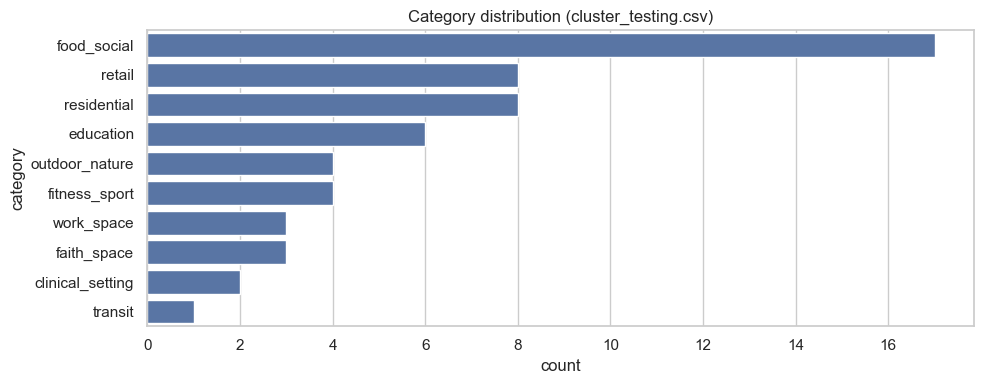

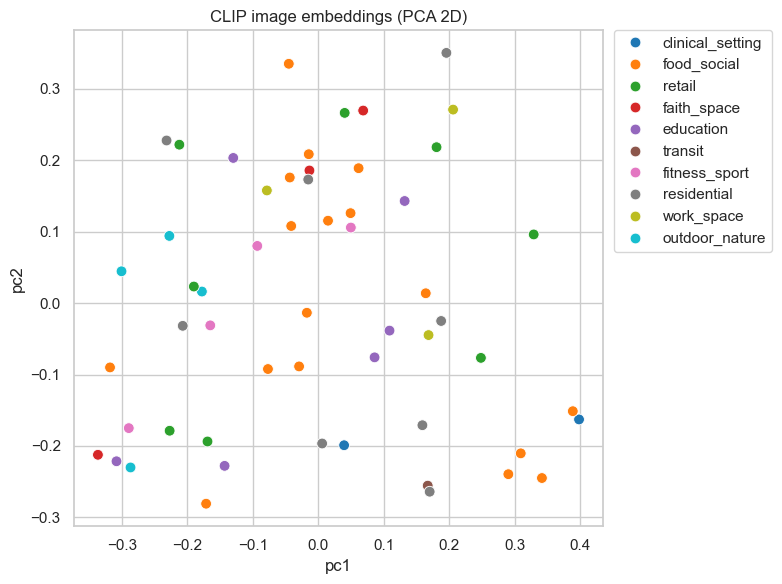

In [5]:
# ── Dataset overview ─────────────────────────────────────────────────────────

labels = df["category"].astype(str).to_numpy()

plt.figure(figsize=(10, 4))
order = pd.Series(labels).value_counts().index.tolist()
sns.countplot(y=labels, order=order)
plt.title("Category distribution (cluster_testing.csv)")
plt.xlabel("count")
plt.ylabel("category")
plt.tight_layout()
plt.show()

# Visual embedding 2D projection (PCA)
vis_2d = pca_2d(embeddings)
plot_df = pd.DataFrame({"pc1": vis_2d[:, 0], "pc2": vis_2d[:, 1], "category": labels})
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="category", palette="tab10", s=60)
plt.title("CLIP image embeddings (PCA 2D)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

,weights,silhouette,ari,precision@5,mrr
0,"(0.3, 0.7)",0.748462,1.0,0.832143,0.982143
1,"(0.5, 0.5)",0.563704,1.0,0.832143,0.982143
2,"(0.7, 0.3)",0.338245,1.0,0.810714,0.982143


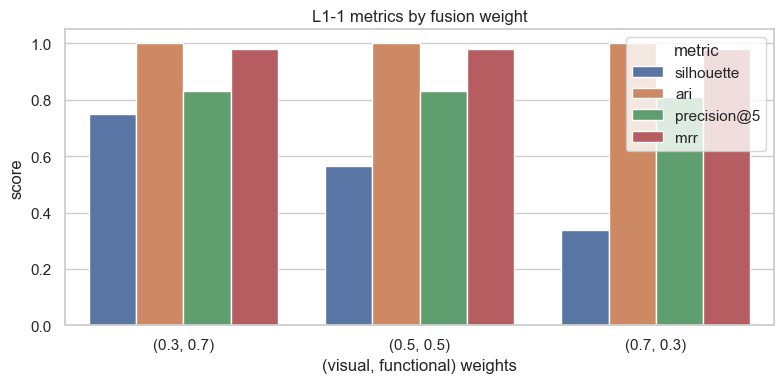

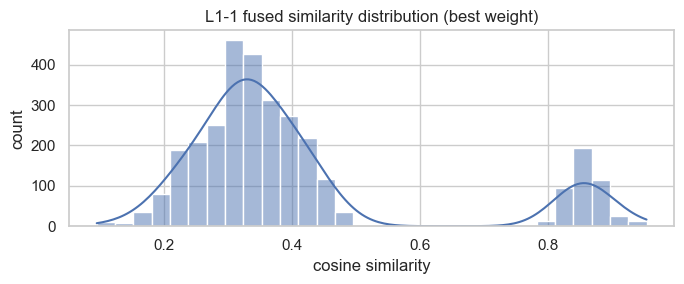

Best L1-1 weights: visual=0.3, functional=0.7


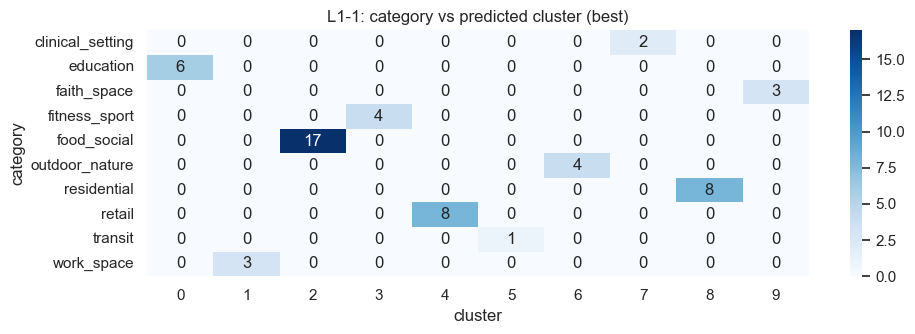

In [6]:
# ── L1-1: Weighted Late Fusion (visual + functional semantic similarity) ──────

vis_vecs = norm_rows(embeddings)
func_semantic_vecs = sentence_semantics(df["place_text"].tolist())

vis_sim = similarity_matrix(vis_vecs)
func_sim = similarity_matrix(func_semantic_vecs)

results_l11 = []
for w_visual, w_function in WEIGHTS:
    sim = combine_similarity(vis_sim, func_sim, w_visual, w_function)
    metrics = evaluate_similarity_method(sim=sim, labels=labels, n_clusters=n_clusters, top_k=TOP_K)
    metrics.update({"w_visual": w_visual, "w_function": w_function})
    results_l11.append(metrics)

# choose best by retrieval (precision@K), then ARI, then silhouette
best_l11 = max(
    results_l11,
    key=lambda item: (
        np.nan_to_num(item[f"precision@{TOP_K}"], nan=-1.0),
        np.nan_to_num(item["ari"], nan=-1.0),
        np.nan_to_num(item["silhouette"], nan=-1.0),
    ),
)

l11_metrics = pd.DataFrame(
    [
        {
            "weights": f"({result['w_visual']:.1f}, {result['w_function']:.1f})",
            "silhouette": result["silhouette"],
            "ari": result["ari"],
            f"precision@{TOP_K}": result[f"precision@{TOP_K}"],
            "mrr": result["mrr"],
        }
        for result in results_l11
    ]
)

display(l11_metrics.sort_values(by=[f"precision@{TOP_K}", "ari", "silhouette"], ascending=False, na_position="last"))

plt.figure(figsize=(8, 4))
melted_l11 = l11_metrics.melt(
    id_vars="weights",
    value_vars=["silhouette", "ari", f"precision@{TOP_K}", "mrr"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=melted_l11, x="weights", y="value", hue="metric")
plt.title("L1-1 metrics by fusion weight")
plt.xlabel("(visual, functional) weights")
plt.ylabel("score")
plt.tight_layout()
plt.show()

plot_similarity_hist(best_l11["sim"], "L1-1 fused similarity distribution (best weight)")

print(f"Best L1-1 weights: visual={best_l11['w_visual']:.1f}, functional={best_l11['w_function']:.1f}")
plot_cluster_vs_category_heatmap(labels, best_l11["y_pred"], "L1-1: category vs predicted cluster (best)")

,metric,value
0,silhouette,0.097795
1,ari,0.144792
2,precision@5,0.542857
3,mrr,0.819103


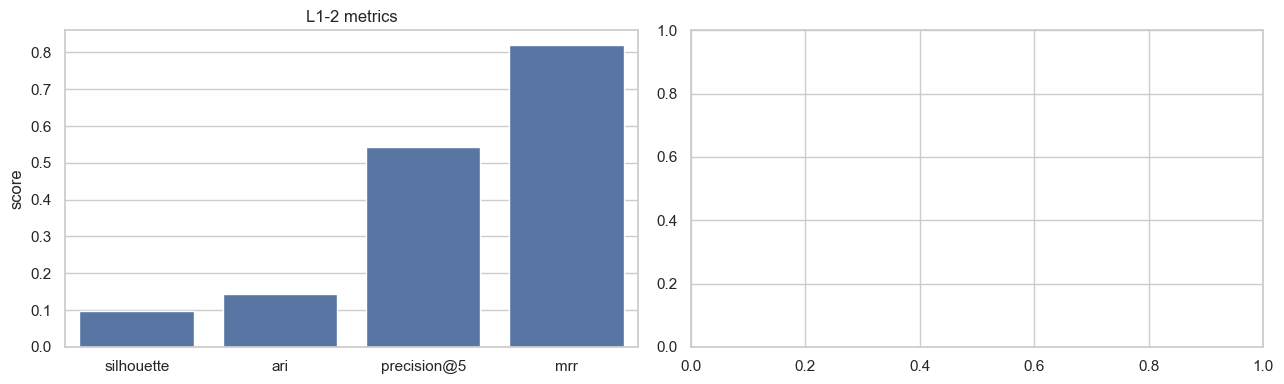

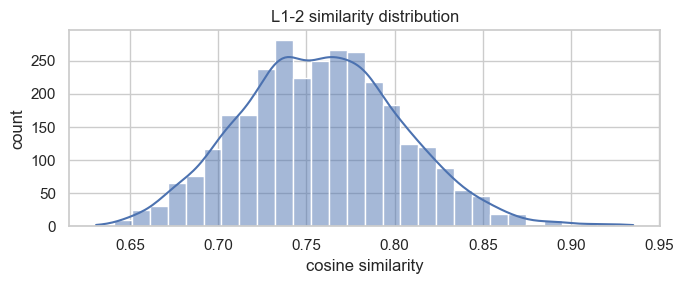

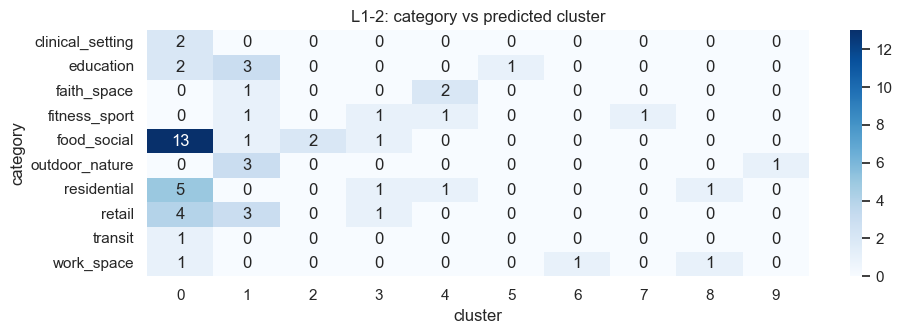

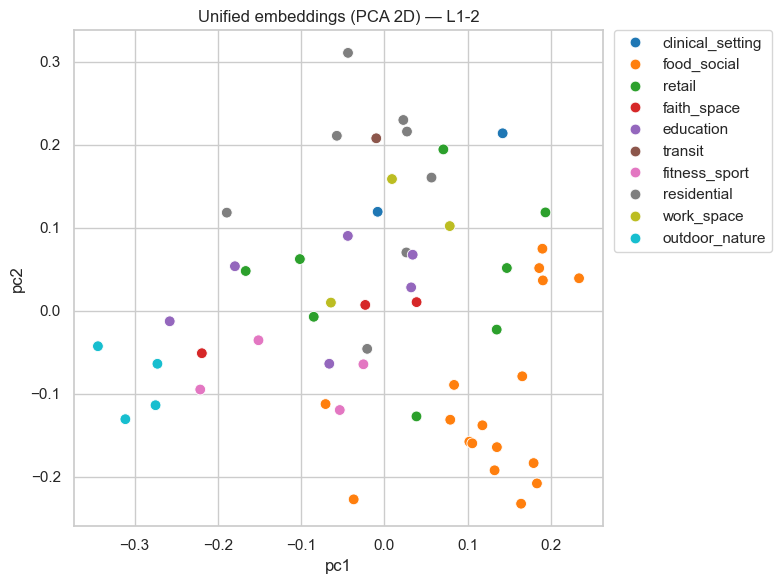

In [7]:
# ── L1-2: Unified Representation (image CLIP + category CLIP text) ────────────

# CLIP text embeddings for functional category text
func_clip_vecs = clip_text_features(df["place_text"].tolist())

unified_vecs = norm_rows(norm_rows(vis_vecs) + norm_rows(func_clip_vecs))
sim_l12 = similarity_matrix(unified_vecs)
results_l12 = evaluate_similarity_method(sim=sim_l12, labels=labels, n_clusters=n_clusters, top_k=TOP_K)

l12_metrics = pd.DataFrame(
    {
        "metric": ["silhouette", "ari", f"precision@{TOP_K}", "mrr"],
        "value": [
            results_l12["silhouette"],
            results_l12["ari"],
            results_l12[f"precision@{TOP_K}"],
            results_l12["mrr"],
        ],
    }
)

display(l12_metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(ax=axes[0], data=l12_metrics, x="metric", y="value")
axes[0].set_title("L1-2 metrics")
axes[0].set_xlabel("")
axes[0].set_ylabel("score")

plt.tight_layout()
plt.show()

plot_similarity_hist(sim_l12, "L1-2 similarity distribution")
plot_cluster_vs_category_heatmap(labels, results_l12["y_pred"], "L1-2: category vs predicted cluster")

# 2D projection of unified embeddings
unified_2d = pca_2d(unified_vecs)
proj_df = pd.DataFrame({"pc1": unified_2d[:, 0], "pc2": unified_2d[:, 1], "category": labels})
plt.figure(figsize=(8, 6))
sns.scatterplot(data=proj_df, x="pc1", y="pc2", hue="category", palette="tab10", s=60)
plt.title("Unified embeddings (PCA 2D) — L1-2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

,metric,value
0,silhouette,0.753084
1,ari,1.000000
2,precision@5,0.832143
3,mrr,0.982143


,place_text,l15_family
0,clinical setting,clinical setting
6,education,education
5,faith space,faith space
8,fitness sport,fitness sport
1,food social,food social
14,outdoor nature,outdoor nature
10,residential,residential
2,retail,retail
7,transit,transit
12,work space,work space


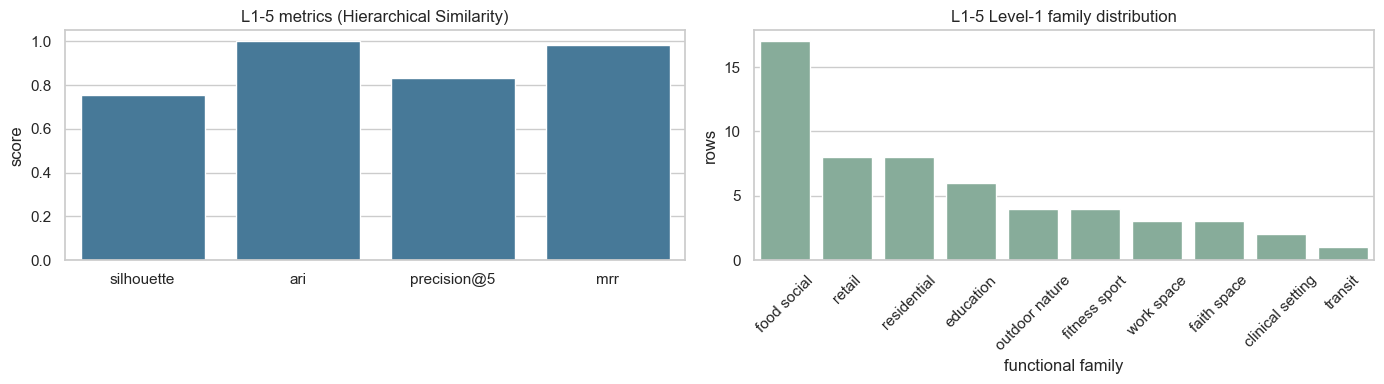

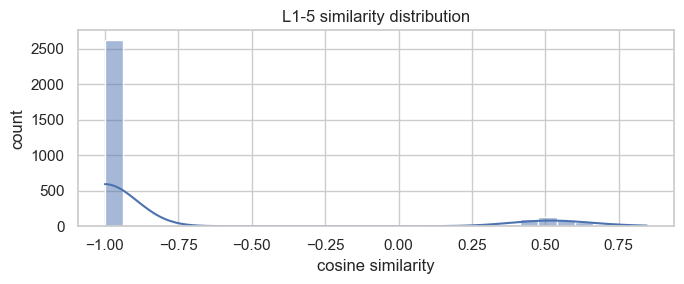

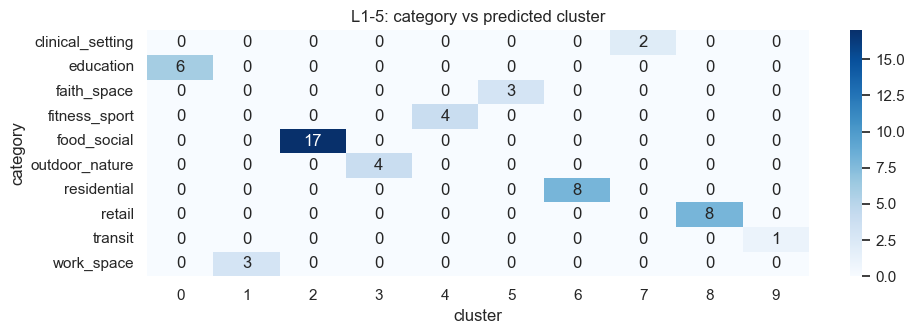

In [8]:
# -- L1-5: Hierarchical Similarity (functional filter -> visual subtype) --

# Step 1: use place_text directly as the L1-5 family label (no keyword logic).
df["l15_family"] = df["place_text"].astype(str).str.lower().str.strip()
category_text = df["place_text"].astype(str).str.lower().to_numpy()
family_text = df["l15_family"].astype(str).to_numpy()

# Level 1 filter: exact category match OR same broad family.
level1_mask = (category_text[:, None] == category_text[None, :]) | (family_text[:, None] == family_text[None, :])

# Level 2 similarity: CLIP visual similarity only within Level 1 candidates.
sim_l15 = np.full_like(vis_sim, -1.0, dtype=np.float32)
sim_l15[level1_mask] = vis_sim[level1_mask]
np.fill_diagonal(sim_l15, 1.0)

results_l15 = evaluate_similarity_method(sim=sim_l15, labels=labels, n_clusters=n_clusters, top_k=TOP_K)

l15_metrics = pd.DataFrame(
    {
        "metric": ["silhouette", "ari", f"precision@{TOP_K}", "mrr"],
        "value": [
            results_l15["silhouette"],
            results_l15["ari"],
            results_l15[f"precision@{TOP_K}"],
            results_l15["mrr"],
        ],
    }
)

display(l15_metrics)
display(df[["place_text", "l15_family"]].drop_duplicates().sort_values(["l15_family", "place_text"]).head(30))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(ax=axes[0], data=l15_metrics, x="metric", y="value", color="#3A7CA5")
axes[0].set_title("L1-5 metrics (Hierarchical Similarity)")
axes[0].set_xlabel("")
axes[0].set_ylabel("score")

family_counts = df["l15_family"].value_counts().reset_index()
family_counts.columns = ["family", "count"]
sns.barplot(ax=axes[1], data=family_counts, x="family", y="count", color="#81B29A")
axes[1].set_title("L1-5 Level-1 family distribution")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xlabel("functional family")
axes[1].set_ylabel("rows")

plt.tight_layout()
plt.show()

plot_similarity_hist(sim_l15, "L1-5 similarity distribution")
plot_cluster_vs_category_heatmap(labels, results_l15["y_pred"], "L1-5: category vs predicted cluster")

,method,silhouette,ari,precision@5,mrr,rank_score
2,L1-5 (hierarchical),0.753084,1.000000,0.832143,0.982143,93.967370
0,L1-1 (best),0.748462,1.000000,0.832143,0.982143,93.962747
1,L1-2,0.097795,0.144792,0.542857,0.819103,55.831431


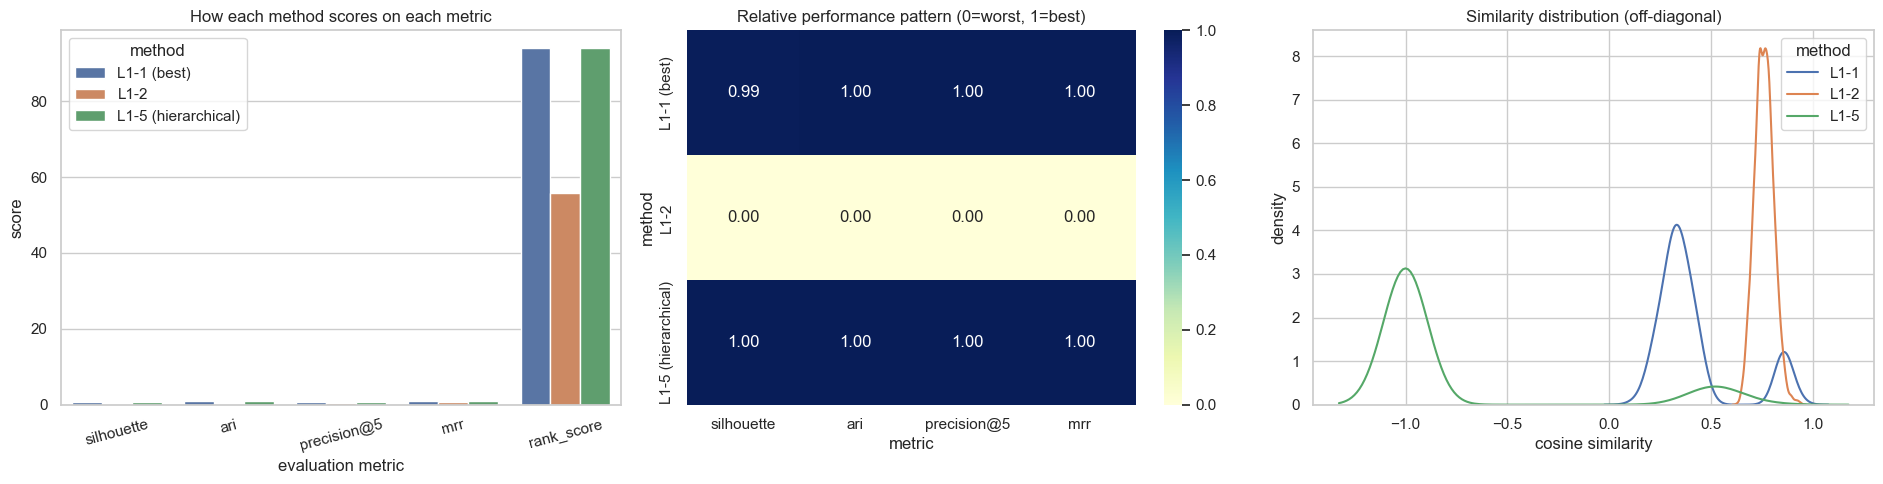

Dataset rows used: 56
Number of functional categories (and clustering target): 10
Best-performing method in this run: L1-5 (hierarchical)

Top-to-bottom ranking by aggregate score:
 - L1-5 (hierarchical): precision@5=0.8321, ARI=1.0000, silhouette=0.7531, MRR=0.9821
 - L1-1 (best): precision@5=0.8321, ARI=1.0000, silhouette=0.7485, MRR=0.9821
 - L1-2: precision@5=0.5429, ARI=0.1448, silhouette=0.0978, MRR=0.8191


In [9]:
## Final comparison (L1-1 vs L1-2 vs L1-5)

comp = pd.DataFrame({
    "method": ["L1-1 (best)", "L1-2", "L1-5 (hierarchical)"],
    "silhouette": [best_l11["silhouette"], results_l12["silhouette"], results_l15["silhouette"]],
    "ari": [best_l11["ari"], results_l12["ari"], results_l15["ari"]],
    f"precision@{TOP_K}": [best_l11[f"precision@{TOP_K}"], results_l12[f"precision@{TOP_K}"], results_l15[f"precision@{TOP_K}"]],
    "mrr": [best_l11["mrr"], results_l12["mrr"], results_l15["mrr"]],
})

comp = comp.assign(
    rank_score=(
        comp[f"precision@{TOP_K}"].fillna(-1) * 100
        + comp["ari"].fillna(-1) * 10
        + comp["silhouette"].fillna(-1)
)
)

display(comp.sort_values("rank_score", ascending=False))

# Descriptive visual 1: method-level metric dashboard
comp_long = comp.melt(id_vars="method", var_name="metric", value_name="value")
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.barplot(data=comp_long, x="metric", y="value", hue="method", ax=axes[0])
axes[0].set_title("How each method scores on each metric")
axes[0].set_xlabel("evaluation metric")
axes[0].set_ylabel("score")
axes[0].tick_params(axis="x", rotation=15)

# Descriptive visual 2: normalized metric heatmap to compare patterns quickly
metric_cols = ["silhouette", "ari", f"precision@{TOP_K}", "mrr"]
norm = comp.set_index("method")[metric_cols].copy()
for col in metric_cols:
    cmin, cmax = norm[col].min(), norm[col].max()
    norm[col] = 0.0 if pd.isna(cmin) or pd.isna(cmax) or cmax == cmin else (norm[col] - cmin) / (cmax - cmin)
sns.heatmap(norm, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, ax=axes[1])
axes[1].set_title("Relative performance pattern (0=worst, 1=best)")
axes[1].set_xlabel("metric")
axes[1].set_ylabel("method")

# Descriptive visual 3: similarity distributions reveal neighborhood structure
for arr, name in [
    (best_l11["sim"], "L1-1"),
    (sim_l12, "L1-2"),
    (sim_l15, "L1-5"),
]:
    mask = ~np.eye(arr.shape[0], dtype=bool)
    sns.kdeplot(arr[mask], label=name, ax=axes[2])
axes[2].set_title("Similarity distribution (off-diagonal)")
axes[2].set_xlabel("cosine similarity")
axes[2].set_ylabel("density")
axes[2].legend(title="method")

plt.tight_layout()
plt.show()

winner = comp.sort_values("rank_score", ascending=False).iloc[0]
print(f"Dataset rows used: {len(df)}")
print(f"Number of functional categories (and clustering target): {n_clusters}")
print(f"Best-performing method in this run: {winner['method']}")
print("\nTop-to-bottom ranking by aggregate score:")
for _, row in comp.sort_values("rank_score", ascending=False).iterrows():
    print(
        f" - {row['method']}: "
        f"precision@{TOP_K}={row[f'precision@{TOP_K}']:.4f}, "
        f"ARI={row['ari']:.4f}, silhouette={row['silhouette']:.4f}, MRR={row['mrr']:.4f}"
    )
if winner["method"] == "L1-1 (best)":
    print(f"Best L1-1 weights: visual={best_l11['w_visual']:.1f}, functional={best_l11['w_function']:.1f}")

## Notes

- This run uses `Other/Dataset/cluster_testing.csv`, which already excludes `unknown_place` categories.
- Metrics are computed against the **functional category** labels (weak labels from OSM / Nominatim), so treat ARI and clustering quality as directional.
- If you increase dataset size (more downloaded OK images), results will generally become more stable.

In [10]:
# Dynamic explanation of the L1-1 vs L1-2 vs L1-5 comparison
# This cell prints a summary using computed `comp` and `winner` variables
try:
    metrics = [f"precision@{TOP_K}", "ari", "silhouette", "mrr"]
    print("Comparison summary:\n")
    print(f"Winner: {winner['method']}")
    print("\nMetric values for the winner:\n")
    for m in metrics:
        if m in comp.columns:
            vals = comp.loc[comp['method'] == winner['method'], m].values
            val = float(vals[0]) if len(vals) else float('nan')
            print(f" - {m}: {val:.4f}" if not np.isnan(val) else f" - {m}: n/a")

    print("\nBest method per metric:\n")
    for m in metrics:
        if m in comp.columns and comp[m].notna().any():
            idx = comp[m].idxmax()
            best_method = comp.loc[idx, 'method']
            best_val = float(comp.loc[idx, m])
            print(f" - {m}: {best_method} ({best_val:.4f})")
        else:
            print(f" - {m}: (no data)")

    prec_key = f"precision@{TOP_K}"
    if prec_key in comp.columns and comp[prec_key].notna().sum() >= 2:
        ranked = comp[["method", prec_key]].dropna().sort_values(prec_key, ascending=False).reset_index(drop=True)
        top = ranked.iloc[0]
        second = ranked.iloc[1]
        margin = float(top[prec_key] - second[prec_key])
        print("\nRetrieval interpretation:")
        print(f" - Top method by {prec_key}: {top['method']}")
        print(f" - Margin over second-best ({second['method']}): {margin:.4f}")
        if abs(margin) < 0.02:
            print(" - The top two methods are very close on retrieval precision.")
        elif margin > 0.08:
            print(" - The lead is strong; retrieval behavior is meaningfully better.")
        else:
            print(" - The lead is moderate; confirm with additional data runs.")
except NameError as e:
    print("Required variables not available in scope (e.g., `comp`, `winner`). Run previous method/comparison cells.")
    print(e)

Comparison summary:

Winner: L1-5 (hierarchical)

Metric values for the winner:

 - precision@5: 0.8321
 - ari: 1.0000
 - silhouette: 0.7531
 - mrr: 0.9821

Best method per metric:

 - precision@5: L1-1 (best) (0.8321)
 - ari: L1-1 (best) (1.0000)
 - silhouette: L1-5 (hierarchical) (0.7531)
 - mrr: L1-1 (best) (0.9821)

Retrieval interpretation:
 - Top method by precision@5: L1-1 (best)
 - Margin over second-best (L1-5 (hierarchical)): 0.0000
 - The top two methods are very close on retrieval precision.


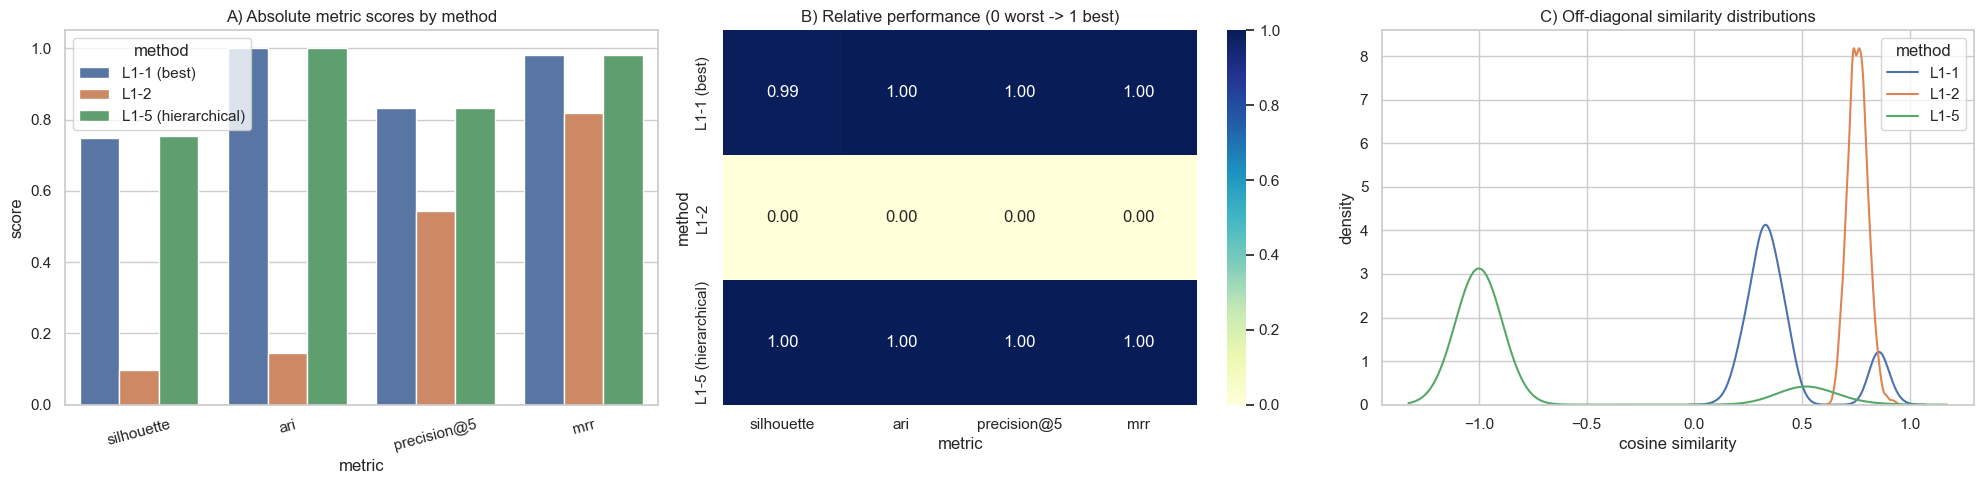

In [11]:
# Visual comparison: all three methods with descriptive labels
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")

    if 'comp' not in globals():
        raise NameError('`comp` not found. Run the final comparison cell first.')

    metric_cols = [c for c in comp.columns if c not in ["method", "rank_score"]]
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Panel A: grouped metric bars
    comp_long = comp[["method", *metric_cols]].melt(id_vars="method", var_name="metric", value_name="value")
    sns.barplot(data=comp_long, x="metric", y="value", hue="method", ax=axes[0])
    axes[0].set_title("A) Absolute metric scores by method")
    axes[0].set_xlabel("metric")
    axes[0].set_ylabel("score")
    axes[0].tick_params(axis="x", rotation=15)

    # Panel B: relative heatmap for quick ranking intuition
    rel = comp.set_index("method")[metric_cols].copy()
    for c in metric_cols:
        cmin, cmax = rel[c].min(), rel[c].max()
        rel[c] = 0.0 if cmax == cmin else (rel[c] - cmin) / (cmax - cmin)
    sns.heatmap(rel, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1], cbar=True)
    axes[1].set_title("B) Relative performance (0 worst -> 1 best)")
    axes[1].set_xlabel("metric")
    axes[1].set_ylabel("method")

    # Panel C: similarity distributions (shape = neighborhood structure)
    has_l11 = 'best_l11' in globals() and isinstance(best_l11, dict) and best_l11.get('sim') is not None
    has_l12 = 'sim_l12' in globals()
    has_l15 = 'sim_l15' in globals()
    if has_l11 and has_l12 and has_l15:
        for arr, name in [(best_l11['sim'], 'L1-1'), (sim_l12, 'L1-2'), (sim_l15, 'L1-5')]:
            arr = np.asarray(arr)
            mask = ~np.eye(arr.shape[0], dtype=bool)
            sns.kdeplot(arr[mask], label=name, ax=axes[2])
        axes[2].set_title("C) Off-diagonal similarity distributions")
        axes[2].set_xlabel("cosine similarity")
        axes[2].set_ylabel("density")
        axes[2].legend(title="method")
    else:
        axes[2].text(0.5, 0.5, 'Run L1-1, L1-2, and L1-5 cells first', ha='center')
        axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Could not create visual comparison:', exc)

In [12]:
# Export similar-image mappings for each method to Layer1Exp/results
from pathlib import Path

def build_similarity_pairs(sim: np.ndarray, image_paths, top_k: int = 5) -> pd.DataFrame:
    image_paths = list(image_paths)
    n = sim.shape[0]
    k = min(top_k, max(n - 1, 1))
    rows = []
    for i in range(n):
        order = np.argsort(-sim[i])
        order = order[order != i][:k]
        for j in order:
            rows.append({
                "image_path": image_paths[i],
                "similar_image_path": image_paths[j],
                "similarity_score": float(sim[i, j]),
            })
    return pd.DataFrame(rows)

try:
    if not all(name in globals() for name in ["best_l11", "sim_l12", "sim_l15", "df", "TOP_K", "REPO_ROOT"]):
        raise NameError("Run L1-1, L1-2, L1-5 and setup cells first.")

    results_dir = Path(REPO_ROOT) / "ml_experiments_anish" / "Layer1Exp" / "results"
    results_dir.mkdir(parents=True, exist_ok=True)

    l1_pairs = build_similarity_pairs(np.asarray(best_l11["sim"]), df["image_path"].tolist(), top_k=TOP_K)
    l2_pairs = build_similarity_pairs(np.asarray(sim_l12), df["image_path"].tolist(), top_k=TOP_K)
    l3_pairs = build_similarity_pairs(np.asarray(sim_l15), df["image_path"].tolist(), top_k=TOP_K)

    p1 = results_dir / "l1.csv"
    p2 = results_dir / "l2.csv"
    p3 = results_dir / "l3.csv"
    l1_pairs.to_csv(p1, index=False)
    l2_pairs.to_csv(p2, index=False)
    l3_pairs.to_csv(p3, index=False)

    print("Export complete:")
    print(f" - {p1} ({len(l1_pairs)} rows)")
    print(f" - {p2} ({len(l2_pairs)} rows)")
    print(f" - {p3} ({len(l3_pairs)} rows)")
except Exception as e:
    print("Could not export similarity CSV files:", e)

Export complete:
 - C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\ml_experiments_anish\Layer1Exp\results\l1.csv (280 rows)
 - C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\ml_experiments_anish\Layer1Exp\results\l2.csv (280 rows)
 - C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\ml_experiments_anish\Layer1Exp\results\l3.csv (280 rows)
